In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)

In [18]:
df1 = pd.read_csv("retail_price.csv")
print("Shape:", df1.shape)
print(df1.dtypes)
print("\nDuplicates:", df1.duplicated().sum())
print("Nulls:\n", df1.isnull().sum()[df1.isnull().sum() > 0])

Shape: (676, 30)
product_id                     object
product_category_name          object
month_year                     object
qty                             int64
total_price                   float64
freight_price                 float64
unit_price                    float64
product_name_lenght             int64
product_description_lenght      int64
product_photos_qty              int64
product_weight_g                int64
product_score                 float64
customers                       int64
weekday                         int64
weekend                         int64
holiday                         int64
month                           int64
year                            int64
s                             float64
volume                          int64
comp_1                        float64
ps1                           float64
fp1                           float64
comp_2                        float64
ps2                           float64
fp2                           flo

In [19]:
df1['month_year'] = pd.to_datetime(df1['month_year'], format='%d-%m-%Y')
df1 = df1.sort_values(['product_id', 'month_year']).reset_index(drop=True)

df1['price_gap_comp1'] = df1['unit_price'] - df1['comp_1']
df1['price_gap_pct'] = (df1['unit_price'] - df1['comp_1']) / df1['comp_1']
df1['revenue'] = df1['qty'] * df1['unit_price']
df1['is_electronics'] = df1['product_category_name'].isin(['consoles_games', 'computers_accessories'])

df1['comp1_flag_suspect'] = df1['price_gap_pct'].abs() > 3
print("Suspect competitor-price rows flagged:", df1['comp1_flag_suspect'].sum())
print("Affected products:", df1[df1['comp1_flag_suspect']]['product_id'].unique())

df1.to_csv("dataset1_clean.csv", index=False)
df1.head()


Suspect competitor-price rows flagged: 41
Affected products: ['health2' 'health3' 'health5' 'health8']


,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_score,customers,weekday,weekend,holiday,month,year,s,volume,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price,price_gap_comp1,price_gap_pct,revenue,is_electronics,comp1_flag_suspect
0,bed1,bed_bath_table,2017-05-01,1,45.95,15.100000,45.95,39,161,2,350,4.0,57,23,8,1,5,2017,10.267394,3800,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90,-43.95,-0.488877,45.95,False,False
1,bed1,bed_bath_table,2017-06-01,3,137.85,12.933333,45.95,39,161,2,350,4.0,61,22,8,1,6,2017,6.503115,3800,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95,-43.95,-0.488877,137.85,False,False
2,bed1,bed_bath_table,2017-07-01,6,275.70,14.840000,45.95,39,161,2,350,4.0,123,21,10,1,7,2017,12.071651,3800,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95,-43.95,-0.488877,275.70,False,False
3,bed1,bed_bath_table,2017-08-01,4,183.80,14.287500,45.95,39,161,2,350,4.0,90,23,8,1,8,2017,9.293873,3800,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95,-43.95,-0.488877,183.80,False,False
4,bed1,bed_bath_table,2017-09-01,2,91.90,15.100000,45.95,39,161,2,350,4.0,54,21,9,1,9,2017,5.555556,3800,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95,-43.95,-0.488877,91.90,False,False


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df1 = pd.read_csv("/content/retail_price.csv")
df1['month_year'] = pd.to_datetime(df1['month_year'], format='%d-%m-%Y')
df1['price_gap_pct'] = (df1['unit_price'] - df1['comp_1']) / df1['comp_1']
df1['revenue'] = df1['qty'] * df1['unit_price']
df1['comp1_flag_suspect'] = df1['price_gap_pct'].abs() > 3
df1['is_electronics'] = df1['product_category_name'].isin(['consoles_games', 'computers_accessories'])

electronics_categories = ['consoles_games', 'computers_accessories']
df1_electronics = df1[df1['product_category_name'].isin(electronics_categories)].copy()
df1_electronics = df1_electronics.sort_values(['product_id', 'month_year']).reset_index(drop=True)

In [28]:
# ===== Filter to Electronics-relevant categories =====
electronics_categories = ['consoles_games', 'computers_accessories']
df1_electronics = df1[df1['product_category_name'].isin(electronics_categories)].copy()

print("Electronics rows:", df1_electronics.shape)
print(df1_electronics['product_category_name'].value_counts())
print("Distinct products:", df1_electronics['product_id'].nunique())
print(df1_electronics['product_id'].unique())

Electronics rows: (91, 34)
product_category_name
computers_accessories    69
consoles_games           22
Name: count, dtype: int64
Distinct products: 8
['consoles1' 'computers5' 'computers6' 'computers1' 'consoles2'
 'computers4' 'computers3' 'computers2']


In [22]:
print("Correlation between price_gap_pct and qty, WITHIN each product:\n")
per_product_corr = {}
for pid, group in df1_electronics.groupby('product_id'):
    if len(group) > 2:  # need at least 3 points for a meaningful correlation
        corr, p_val = stats.pearsonr(group['price_gap_pct'], group['qty'])
        per_product_corr[pid] = {'n_rows': len(group), 'correlation': corr, 'p_value': p_val}
        print(f"{pid}: n={len(group)}, corr={corr:.3f}, p-value={p_val:.3f}")

corr_df = pd.DataFrame(per_product_corr).T
print("\nSummary:")
print(corr_df)

Correlation between price_gap_pct and qty, WITHIN each product:

computers1: n=15, corr=-0.471, p-value=0.077
computers2: n=10, corr=-0.841, p-value=0.002
computers3: n=10, corr=0.125, p-value=0.731
computers4: n=18, corr=nan, p-value=nan
computers5: n=8, corr=-0.636, p-value=0.090
computers6: n=8, corr=-0.384, p-value=0.348
consoles1: n=12, corr=nan, p-value=nan
consoles2: n=10, corr=-0.026, p-value=0.944

Summary:
            n_rows  correlation   p_value
computers1    15.0    -0.470600  0.076659
computers2    10.0    -0.841345  0.002278
computers3    10.0     0.124738  0.731341
computers4    18.0          NaN       NaN
computers5     8.0    -0.635596  0.090320
computers6     8.0    -0.383554  0.348256
consoles1     12.0          NaN       NaN
consoles2     10.0    -0.025838  0.943516


/tmp/ipykernel_1316/1560232896.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = stats.pearsonr(group['price_gap_pct'], group['qty'])


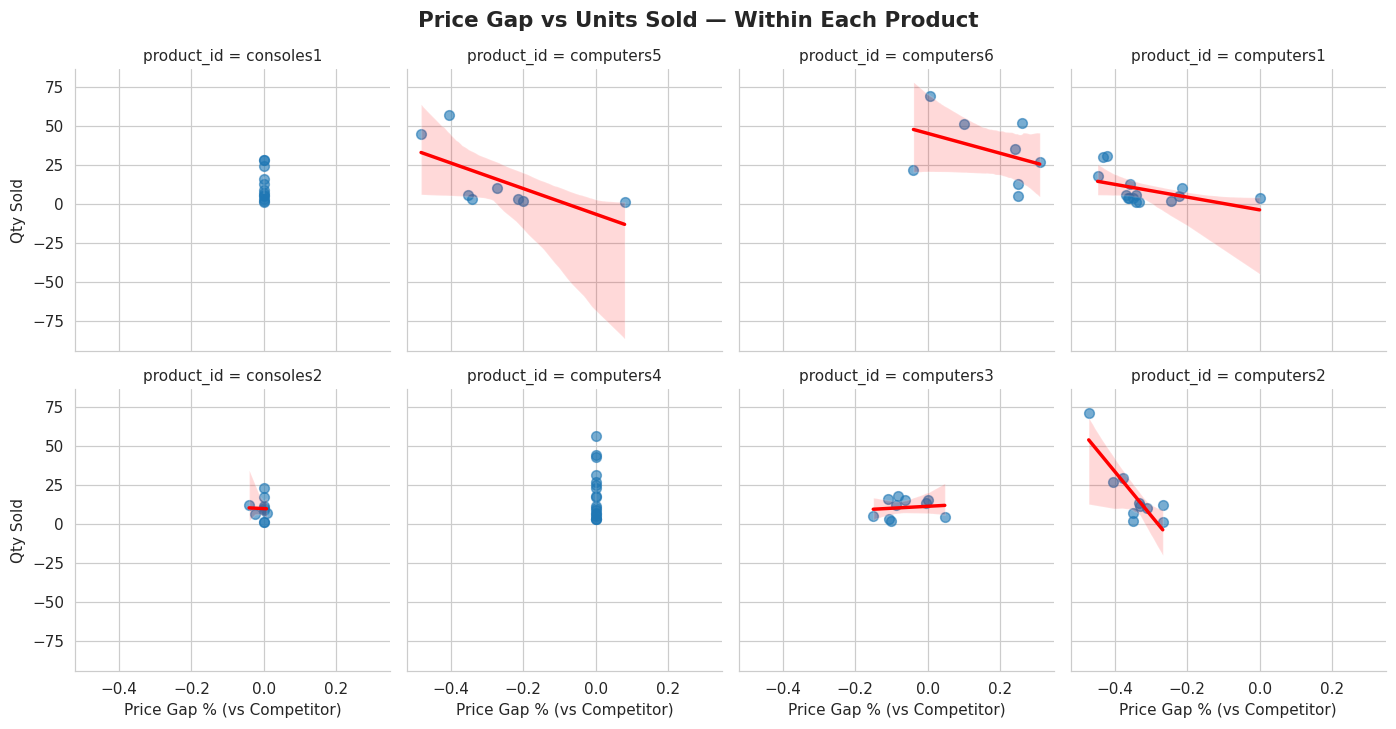

In [23]:
g = sns.lmplot(
    data=df1_electronics, x='price_gap_pct', y='qty',
    col='product_id', col_wrap=4, height=3.2,
    scatter_kws={'alpha':0.6, 's':40}, line_kws={'color':'red'}
)
g.fig.suptitle("Price Gap vs Units Sold — Within Each Product", y=1.03, fontsize=14, fontweight='bold')
g.set_axis_labels("Price Gap % (vs Competitor)", "Qty Sold")
plt.savefig("price_gap_per_product.png", bbox_inches='tight', dpi=110)
plt.show()

In [24]:
import statsmodels.formula.api as smf

model = smf.ols('qty ~ price_gap_pct + C(product_id)', data=df1_electronics).fit()
print(model.summary())

print("\n--- Key takeaway ---")
coef = model.params['price_gap_pct']
pval = model.pvalues['price_gap_pct']
print(f"price_gap_pct coefficient: {coef:.3f} (p-value: {pval:.4f})")
if pval < 0.05:
    direction = "increases" if coef > 0 else "decreases"
    print(f"Statistically significant: a higher price gap (pricing above competitor) {direction} qty sold.")
else:
    print("Not statistically significant at the 5% level with this sample size.")

                            OLS Regression Results                            
Dep. Variable:                    qty   R-squared:                       0.328
Model:                            OLS   Adj. R-squared:                  0.262
Method:                 Least Squares   F-statistic:                     4.995
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           4.62e-05
Time:                        13:02:51   Log-Likelihood:                -361.92
No. Observations:                  91   AIC:                             741.8
Df Residuals:                      82   BIC:                             764.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [25]:
# ===== Build the final training-ready dataset =====
df1_electronics['price_gap_comp1'] = df1_electronics['unit_price'] - df1_electronics['comp_1']
df1_electronics['comp1_flag_suspect'] = df1_electronics['price_gap_pct'].abs() > 3

model_cols = [
    'product_id', 'product_category_name', 'month_year',
    'unit_price', 'qty', 'revenue',
    'comp_1', 'comp_2', 'comp_3',
    'price_gap_comp1', 'price_gap_pct',
    'weekday', 'weekend', 'holiday', 'month', 'year',
    'freight_price', 'product_score', 'customers', 'lag_price'
]

df1_electronics_ready = df1_electronics[model_cols].copy()
df1_electronics_ready = df1_electronics_ready.sort_values(['product_id', 'month_year']).reset_index(drop=True)

print("Final shape:", df1_electronics_ready.shape)
print(df1_electronics_ready.dtypes)
df1_electronics_ready.head()

# ===== Export to CSV =====
df1_electronics_ready.to_csv("dataset1_electronics_ready.csv", index=False)

# ===== Download it to your computer =====
from google.colab import files
files.download("dataset1_electronics_ready.csv")

Final shape: (91, 20)
product_id                       object
product_category_name            object
month_year               datetime64[ns]
unit_price                      float64
qty                               int64
revenue                         float64
comp_1                          float64
comp_2                          float64
comp_3                          float64
price_gap_comp1                 float64
price_gap_pct                   float64
weekday                           int64
weekend                           int64
holiday                           int64
month                             int64
year                              int64
freight_price                   float64
product_score                   float64
customers                         int64
lag_price                       float64
dtype: object


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

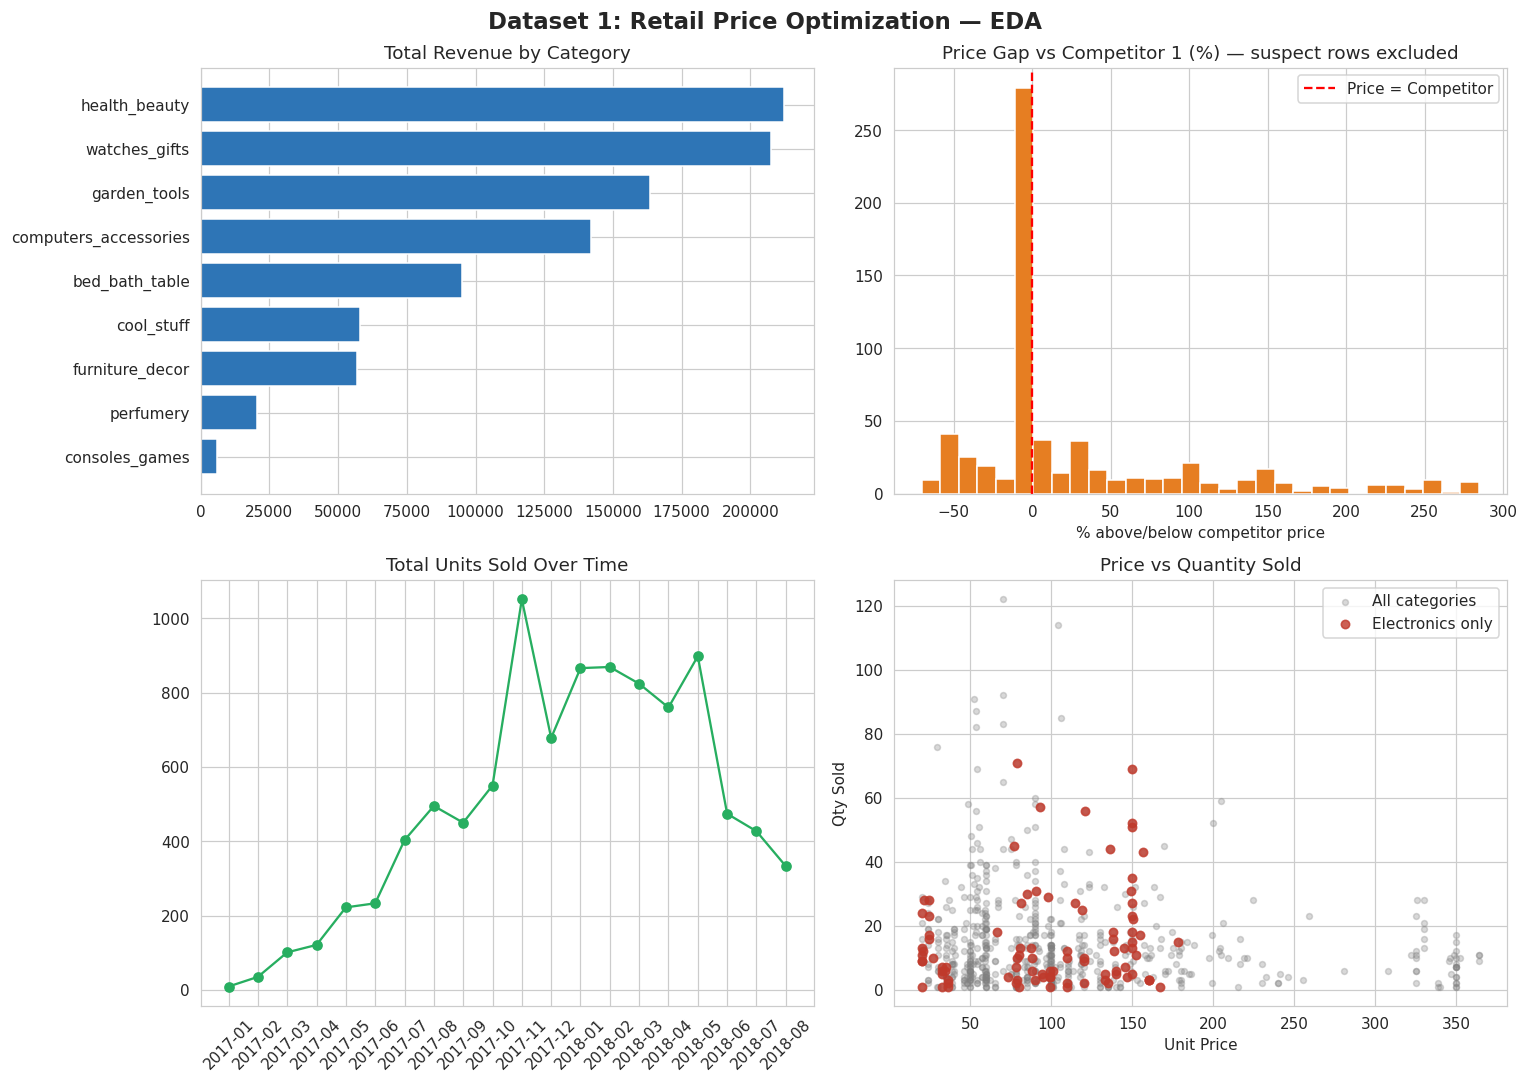

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Dataset 1: Retail Price Optimization — EDA", fontsize=15, fontweight='bold')

cat_rev = df1.groupby('product_category_name')['revenue'].sum().sort_values(ascending=False)
axes[0,0].barh(cat_rev.index, cat_rev.values, color='#2E75B6')
axes[0,0].set_title("Total Revenue by Category")
axes[0,0].invert_yaxis()

clean_gap = df1[~df1['comp1_flag_suspect']]
axes[0,1].hist(clean_gap['price_gap_pct'] * 100, bins=30, color='#E67E22', edgecolor='white')
axes[0,1].axvline(0, color='red', linestyle='--', label='Price = Competitor')
axes[0,1].set_title("Price Gap vs Competitor 1 (%) — suspect rows excluded")
axes[0,1].set_xlabel("% above/below competitor price")
axes[0,1].legend()

monthly = df1.groupby(df1['month_year'].dt.to_period('M'))['qty'].sum()
axes[1,0].plot(monthly.index.astype(str), monthly.values, marker='o', color='#27AE60')
axes[1,0].set_title("Total Units Sold Over Time")
axes[1,0].tick_params(axis='x', rotation=45)

elec = df1[df1['is_electronics']]
axes[1,1].scatter(df1['unit_price'], df1['qty'], alpha=0.3, s=15, color='gray', label='All categories')
axes[1,1].scatter(elec['unit_price'], elec['qty'], alpha=0.8, s=30, color='#C0392B', label='Electronics only')
axes[1,1].set_title("Price vs Quantity Sold")
axes[1,1].set_xlabel("Unit Price")
axes[1,1].set_ylabel("Qty Sold")
axes[1,1].legend()

plt.tight_layout()
plt.savefig("eda_dataset1.png", bbox_inches='tight')
plt.show()

In [31]:
df2 = pd.read_csv("/content/electronics sales dataset.csv")
print("Shape:", df2.shape)
print(df2.dtypes)
print("\nDuplicates:", df2.duplicated().sum())
print("Nulls:\n", df2.isnull().sum()[df2.isnull().sum() > 0])

Shape: (20000, 16)
Customer ID            int64
Age                    int64
Gender                object
Loyalty Member        object
Product Type          object
SKU                   object
Rating                 int64
Order Status          object
Payment Method        object
Total Price          float64
Unit Price           float64
Quantity               int64
Purchase Date         object
Shipping Type         object
Add-ons Purchased     object
Add-on Total         float64
dtype: object

Duplicates: 0
Nulls:
 Gender                  1
Add-ons Purchased    4868
dtype: int64


In [32]:
df2['Purchase Date'] = pd.to_datetime(df2['Purchase Date'])
df2['Gender'] = df2['Gender'].fillna('Unknown')
df2['Add-ons Purchased'] = df2['Add-ons Purchased'].fillna('None')
df2['Add-on Total'] = df2['Add-on Total'].fillna(0)
df2['Has_Addon'] = df2['Add-ons Purchased'] != 'None'
df2['Num_Addons'] = df2['Add-ons Purchased'].apply(lambda x: 0 if x == 'None' else len(x.split(',')))
df2['Is_Cancelled'] = df2['Order Status'] == 'Cancelled'
df2['Month'] = df2['Purchase Date'].dt.to_period('M').astype(str)

print("Cancelled orders:", df2['Is_Cancelled'].sum(), f"({df2['Is_Cancelled'].mean()*100:.1f}%)")

df2.to_csv("dataset2_clean.csv", index=False)
df2.head()

Cancelled orders: 6568 (32.8%)


/tmp/ipykernel_1316/2183871210.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df2['Purchase Date'] = pd.to_datetime(df2['Purchase Date'])


,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total,Has_Addon,Num_Addons,Is_Cancelled,Month
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21,True,3,True,2024-03
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09,True,1,False,2024-04
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,None,0.00,False,0,False,2023-10
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16,True,2,False,2024-08
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56,True,1,False,2024-05


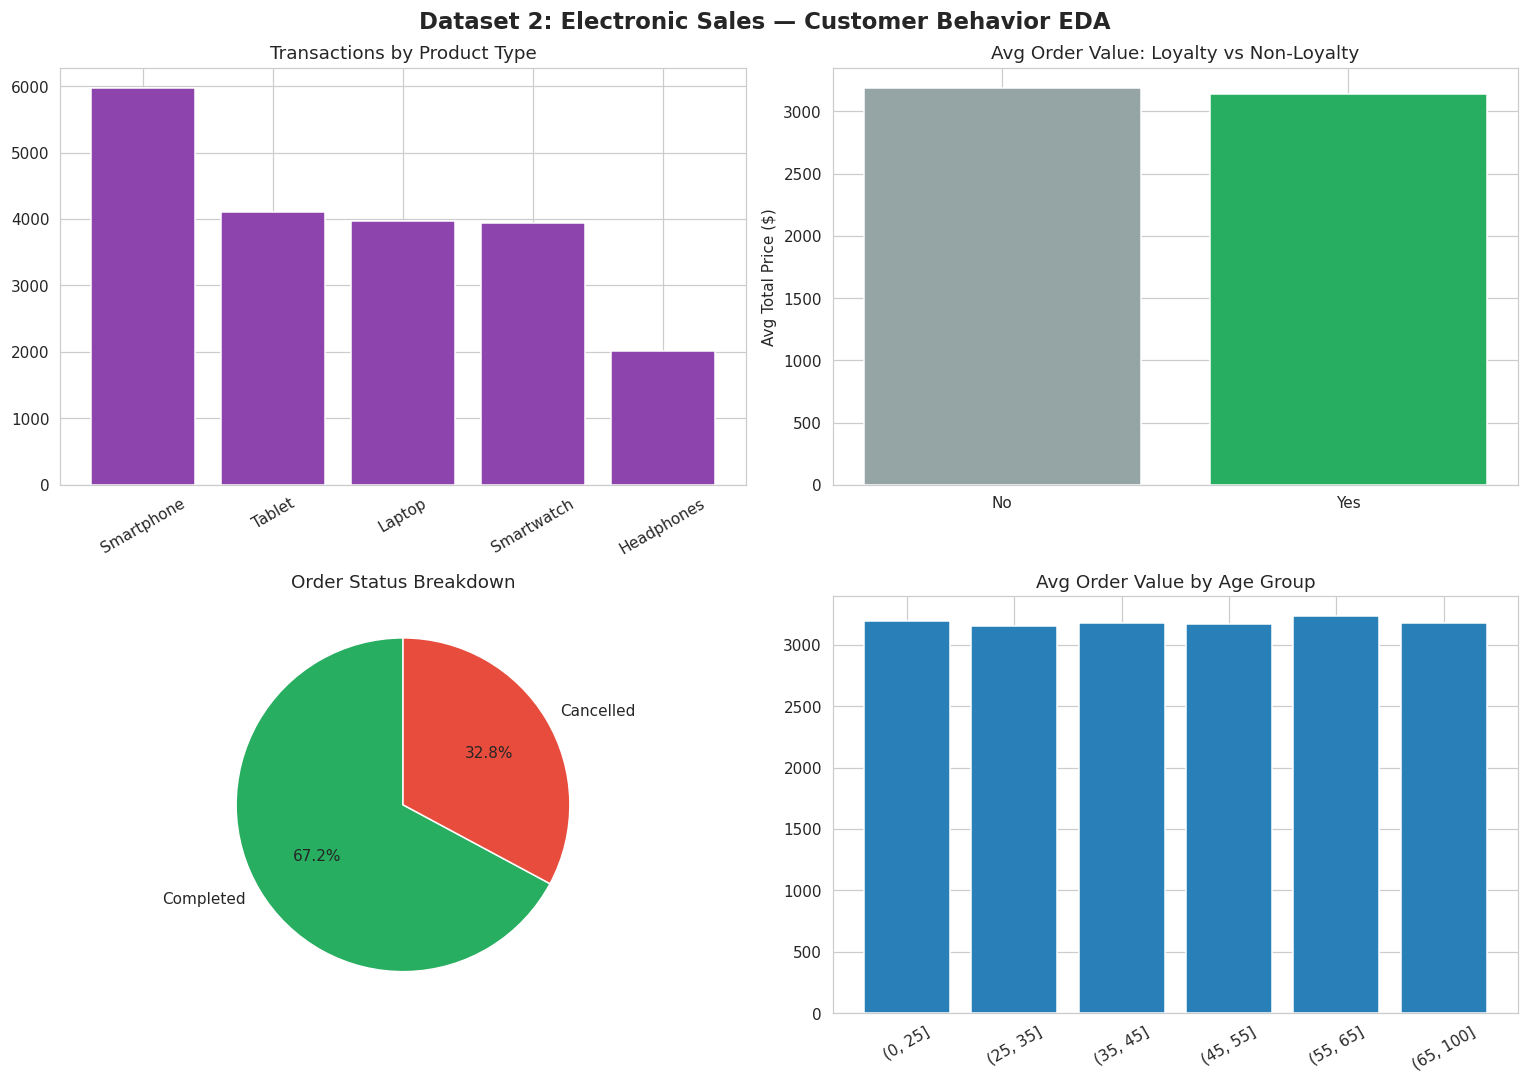

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Dataset 2: Electronic Sales — Customer Behavior EDA", fontsize=15, fontweight='bold')

prod_counts = df2['Product Type'].value_counts()
axes[0,0].bar(prod_counts.index, prod_counts.values, color='#8E44AD')
axes[0,0].set_title("Transactions by Product Type")
axes[0,0].tick_params(axis='x', rotation=30)

loyalty_spend = df2.groupby('Loyalty Member')['Total Price'].mean()
axes[0,1].bar(loyalty_spend.index, loyalty_spend.values, color=['#95A5A6', '#27AE60'])
axes[0,1].set_title("Avg Order Value: Loyalty vs Non-Loyalty")
axes[0,1].set_ylabel("Avg Total Price ($)")

status_counts = df2['Order Status'].value_counts()
axes[1,0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
              colors=['#27AE60', '#E74C3C'], startangle=90)
axes[1,0].set_title("Order Status Breakdown")

age_bins = pd.cut(df2['Age'], bins=[0, 25, 35, 45, 55, 65, 100])
age_spend = df2.groupby(age_bins, observed=True)['Total Price'].mean()
axes[1,1].bar(age_spend.index.astype(str), age_spend.values, color='#2980B9')
axes[1,1].set_title("Avg Order Value by Age Group")
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("eda_dataset2.png", bbox_inches='tight')
plt.show()

In [34]:
# ===== CELL 9: Loyalty t-test =====
loyal = df2[df2['Loyalty Member'] == 'Yes']['Total Price']
non_loyal = df2[df2['Loyalty Member'] == 'No']['Total Price']
t_stat, p_val = stats.ttest_ind(loyal, non_loyal, equal_var=False)
print(f"t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")
print("Statistically significant (p < 0.05)?", p_val < 0.05)

t-statistic: -1.262, p-value: 0.2070
Statistically significant (p < 0.05)? False


In [35]:
df3 = pd.read_csv("/content/retail store inventory dataset.csv")
print("Shape:", df3.shape)
print(df3.columns.tolist())
print(df3.dtypes)
print("\nDuplicates:", df3.duplicated().sum())
print("Nulls:\n", df3.isnull().sum()[df3.isnull().sum() > 0])

Shape: (73100, 15)
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']
Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition      object
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality            object
dtype: object

Duplicates: 0
Nulls:
 Series([], dtype: int64)


In [36]:
df3['Date'] = pd.to_datetime(df3['Date'], format='%d-%m-%Y')
df3 = df3.sort_values(['Product ID', 'Date']).reset_index(drop=True)

df3['price_gap'] = df3['Price'] - df3['Competitor Pricing']
df3['price_gap_pct'] = (df3['Price'] - df3['Competitor Pricing']) / df3['Competitor Pricing']
df3['revenue'] = df3['Units Sold'] * df3['Price']
df3['is_electronics'] = df3['Category'] == 'Electronics'
df3['forecast_error'] = df3['Units Sold'] - df3['Demand Forecast']

print("Electronics rows:", df3['is_electronics'].sum(), f"({df3['is_electronics'].mean()*100:.1f}%)")

df3.to_csv("dataset3_clean.csv", index=False)
df3.head()

Electronics rows: 14521 (19.9%)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,price_gap,price_gap_pct,revenue,is_electronics,forecast_error
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.5,20,Rainy,0,29.69,Autumn,3.81,0.128326,4254.5,False,-8.47
1,2022-01-01,S002,P0001,Groceries,South,343,104,144,112.55,33.5,20,Sunny,1,30.78,Spring,2.72,0.088369,3484.0,False,-8.55
2,2022-01-01,S003,P0001,Toys,South,241,147,180,161.09,33.5,5,Sunny,1,67.39,Summer,-33.89,-0.502894,4924.5,False,-14.09
3,2022-01-01,S004,P0001,Toys,South,477,271,66,286.65,33.5,15,Sunny,0,16.09,Winter,17.41,1.082039,9078.5,False,-15.65
4,2022-01-01,S005,P0001,Toys,West,111,77,60,83.47,33.5,10,Cloudy,0,70.29,Winter,-36.79,-0.523403,2579.5,False,-6.47


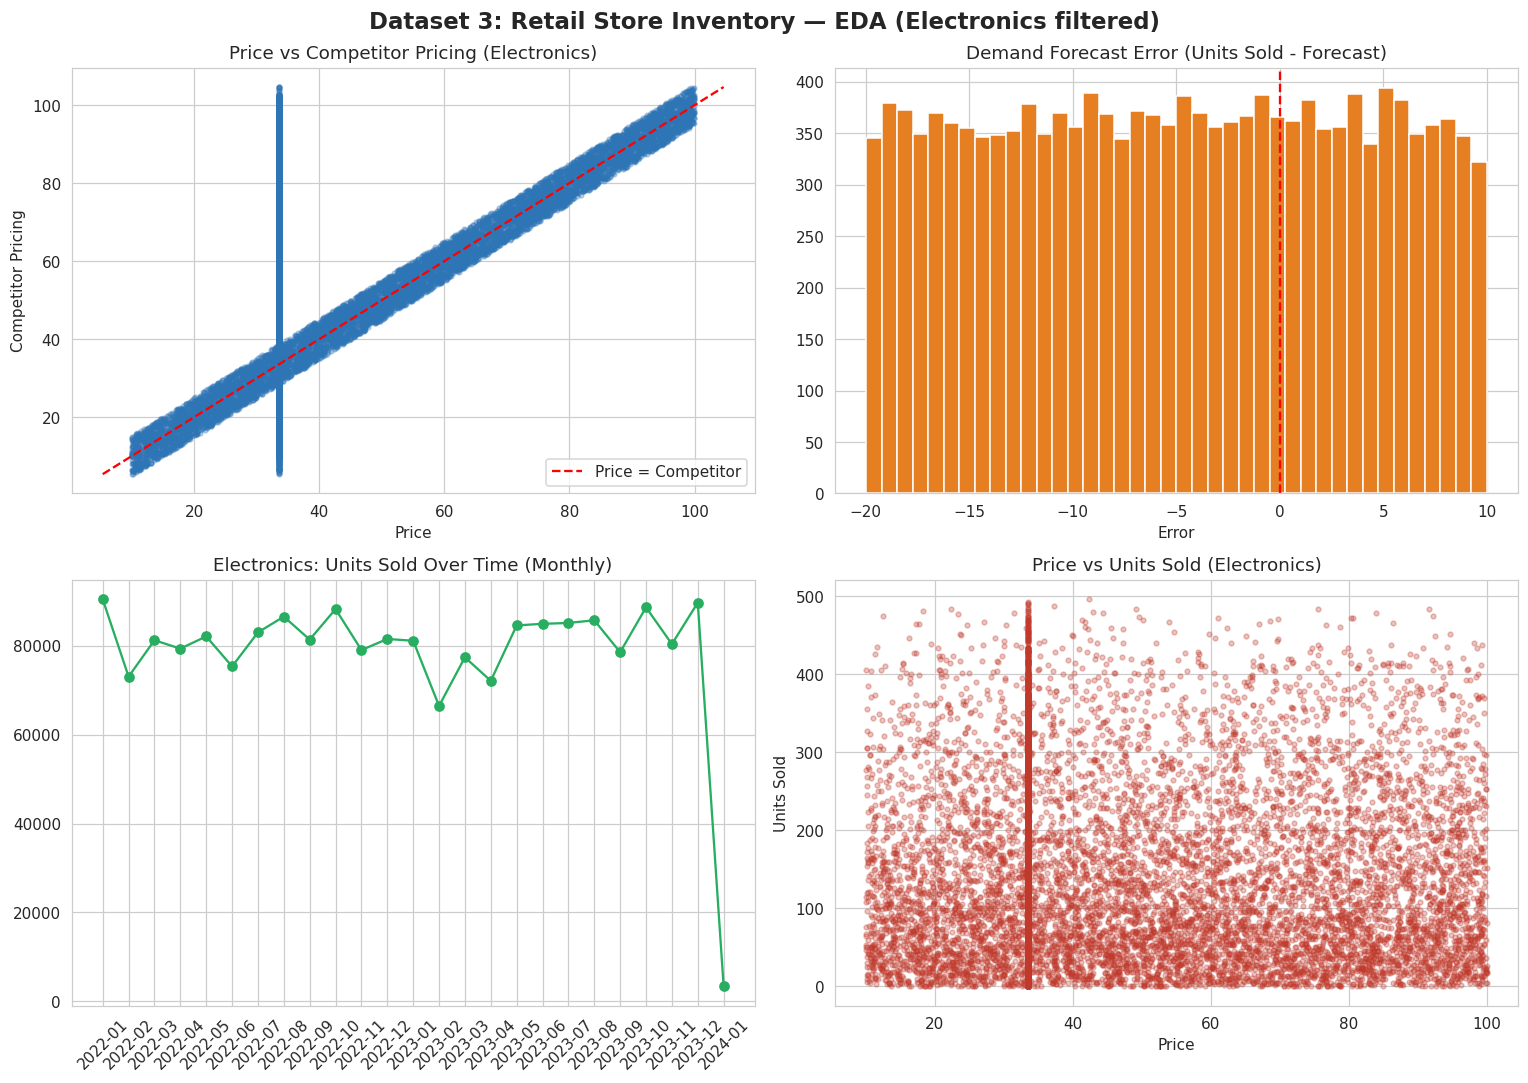

In [37]:
elec3 = df3[df3['is_electronics']].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Dataset 3: Retail Store Inventory — EDA (Electronics filtered)", fontsize=15, fontweight='bold')

axes[0,0].scatter(elec3['Price'], elec3['Competitor Pricing'], alpha=0.3, s=10, color='#2E75B6')
lims = [elec3[['Price','Competitor Pricing']].min().min(), elec3[['Price','Competitor Pricing']].max().max()]
axes[0,0].plot(lims, lims, 'r--', label='Price = Competitor')
axes[0,0].set_title("Price vs Competitor Pricing (Electronics)")
axes[0,0].set_xlabel("Price"); axes[0,0].set_ylabel("Competitor Pricing")
axes[0,0].legend()

axes[0,1].hist(elec3['forecast_error'], bins=40, color='#E67E22', edgecolor='white')
axes[0,1].axvline(0, color='red', linestyle='--')
axes[0,1].set_title("Demand Forecast Error (Units Sold - Forecast)")
axes[0,1].set_xlabel("Error")

daily = elec3.groupby(elec3['Date'].dt.to_period('M'))['Units Sold'].sum()
axes[1,0].plot(daily.index.astype(str), daily.values, marker='o', color='#27AE60')
axes[1,0].set_title("Electronics: Units Sold Over Time (Monthly)")
axes[1,0].tick_params(axis='x', rotation=45)

axes[1,1].scatter(elec3['Price'], elec3['Units Sold'], alpha=0.3, s=10, color='#C0392B')
axes[1,1].set_title("Price vs Units Sold (Electronics)")
axes[1,1].set_xlabel("Price"); axes[1,1].set_ylabel("Units Sold")

plt.tight_layout()
plt.savefig("eda_dataset3.png", bbox_inches='tight')
plt.show()

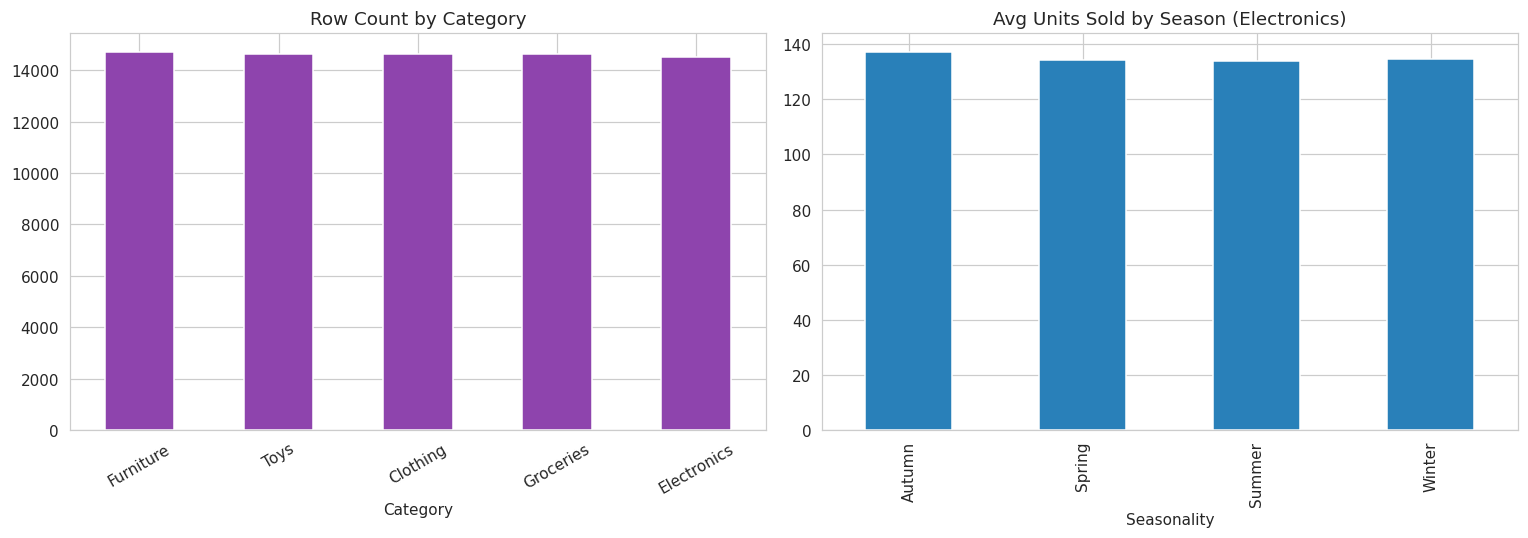

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df3['Category'].value_counts().plot(kind='bar', ax=axes[0], color='#8E44AD')
axes[0].set_title("Row Count by Category")
axes[0].tick_params(axis='x', rotation=30)

if 'Seasonality' in df3.columns:
    elec3.groupby('Seasonality')['Units Sold'].mean().plot(kind='bar', ax=axes[1], color='#2980B9')
    axes[1].set_title("Avg Units Sold by Season (Electronics)")

plt.tight_layout()
plt.savefig("eda_dataset3_categories.png", bbox_inches='tight')
plt.show()

In [39]:
check = pd.read_csv("retail_price.csv")
print(check.columns.tolist())
print(check.shape)
check.head(2)

['product_id', 'product_category_name', 'month_year', 'qty', 'total_price', 'freight_price', 'unit_price', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month', 'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2', 'comp_3', 'ps3', 'fp3', 'lag_price']
(676, 30)


,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_score,customers,weekday,weekend,holiday,month,year,s,volume,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,350,4.0,57,23,8,1,5,2017,10.267394,3800,89.9,3.9,15.011897,215.0,4.4,8.760,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,350,4.0,61,22,8,1,6,2017,6.503115,3800,89.9,3.9,14.769216,209.0,4.4,21.322,45.95,4.0,12.933333,45.95


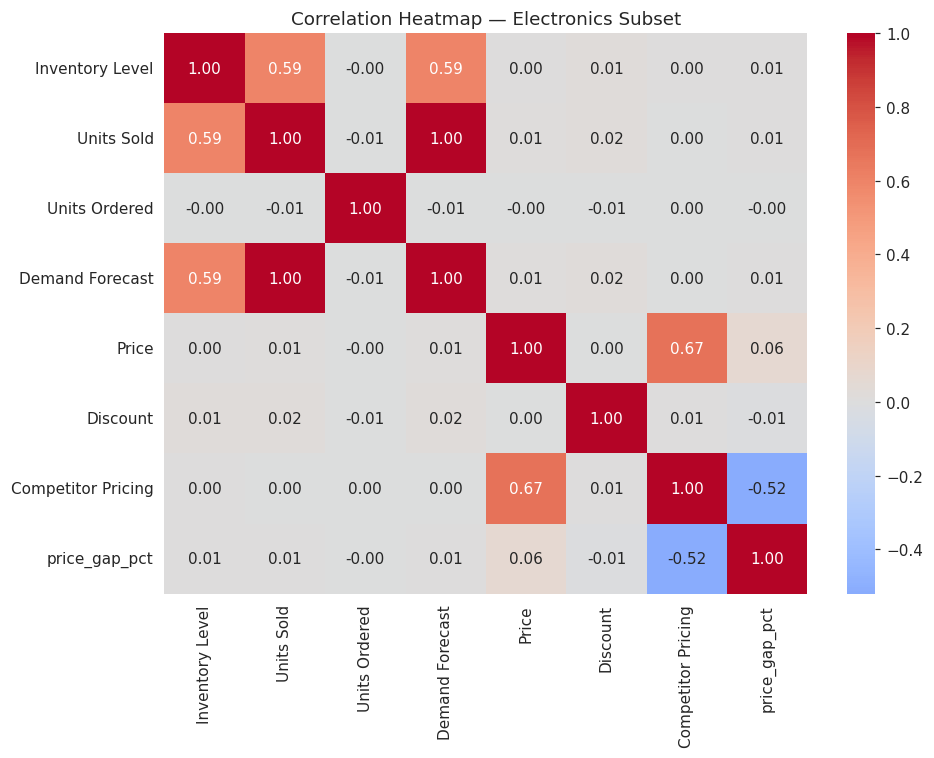

In [44]:
numeric_cols = ['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
                 'Price', 'Discount', 'Competitor Pricing', 'price_gap_pct']
corr = elec3[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation Heatmap — Electronics Subset")
plt.tight_layout()
plt.savefig("eda_dataset3_correlation.png", bbox_inches='tight')
plt.show()

In [45]:
model_cols = [
    'Date', 'Store ID', 'Product ID', 'Region',
    'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
    'Price', 'Discount', 'Competitor Pricing', 'price_gap', 'price_gap_pct',
    'Weather Condition', 'Holiday/Promotion', 'Seasonality',
    'Month', 'DayOfWeek', 'Is_Weekend', 'revenue', 'forecast_error'
]

elec3['Month'] = elec3['Date'].dt.month
elec3['DayOfWeek'] = elec3['Date'].dt.dayofweek
elec3['Is_Weekend'] = elec3['Date'].dt.weekday >= 5 # Saturday (5) or Sunday (6)

df3_electronics_ready = elec3[model_cols].copy()
df3_electronics_ready = df3_electronics_ready.sort_values(['Product ID', 'Date']).reset_index(drop=True)

print("Final shape:", df3_electronics_ready.shape)
df3_electronics_ready.to_csv("dataset3_electronics_ready.csv", index=False)

from google.colab import files

/tmp/ipykernel_1316/835377981.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  elec3['Month'] = elec3['Date'].dt.month
/tmp/ipykernel_1316/835377981.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  elec3['DayOfWeek'] = elec3['Date'].dt.dayofweek
/tmp/ipykernel_1316/835377981.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

Final shape: (14521, 21)


In [48]:
!git clone https://github.com/springboardmentor12233a-tech/PricePilot-AI-.git

Cloning into 'PricePilot-AI-'...
remote: Enumerating objects: 574, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 574 (delta 13), reused 39 (delta 9), pack-reused 515 (from 1)
Receiving objects: 100% (574/574), 151.03 MiB | 23.95 MiB/s, done.
Resolving deltas: 100% (108/108), done.


In [49]:
%cd PricePilot-AI-

/content/PricePilot-AI-


In [50]:
!git checkout sadhana_prakash


Branch 'sadhana_prakash' set up to track remote branch 'sadhana_prakash' from 'origin'.
Switched to a new branch 'sadhana_prakash'


In [56]:
# ===== Step 4: Copy your notebook into the repo folder =====
!cp /content/Milestone1-eda.ipynb .

cp: cannot stat '/content/Milestone1-eda.ipynb': No such file or directory


In [55]:
import os
print(os.listdir('/content'))

['.config', 'dataset3_electronics_ready.csv', 'retail_price.csv', 'price_gap_per_product.png', 'retail store inventory dataset.csv', 'eda_dataset3_correlation.png', 'dataset1_electronics_ready.csv', 'electronics sales dataset.csv', 'dataset1_clean.csv', 'eda_dataset1.png', 'dataset2_clean.csv', 'eda_dataset2.png', 'eda_dataset3.png', 'dataset3_clean.csv', 'PricePilot-AI-', 'eda_dataset3_categories.png', 'sample_data']
